# Tanager Mangrove Mapping - 01 Preprocessing

| | |
|---|---|
| **Authors**     | Muhammad Wahyu Ramadhan, Athar Abdurrahman B., Diniyarti |
| **Competition** | Planet Tanager Open Data Competition 2026 |
| **Topic**       | Transferable Mangrove Extent Mapping Using Adaptive Spectral Thresholds |
| **Date**        | June 2026 |

---

**Scope:** HDF5 structure inspection, band extraction, spectral index computation, adaptive threshold calibration per scene.

## 0. Environment Setup

In [ ]:
# Install dependencies (commented out for production)
# !pip install h5py xarray rioxarray rasterio geopandas scipy matplotlib
!pip install contextily

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
import os
from pathlib import Path
from scipy.ndimage import distance_transform_edt

import numpy as np
import matplotlib.pyplot as plt
import h5py
import contextily as cx

# ============================================================
# Project root - adjust per environment
# ============================================================
# Google Colab (Google Drive mounted)
ROOT = Path('/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping')

# Local (uncomment if running locally)
# ROOT = Path('..').resolve()

DATA_RAW  = ROOT / 'data' / 'raw'
DATA_PROC = ROOT / 'data' / 'processed'

sys.path.insert(0, str(ROOT))

from src.preprocessing import (
    inspect_hdf5,
    load_hdf5,
    hdf5_to_geotiff,
    load_geotiff_bands,
    compute_all_indices,
    compute_water_mask,
    compute_coastal_candidate_mask,
    apply_adaptive_threshold,
    compute_reip,
    RELEVANT_WAVELENGTHS
)

from src.spatial_viz import reproject_array_to_4326, format_map_axes

# Unset pyproj PROJ env vars before importing contextily
os.environ.pop('PROJ_LIB',  None)
os.environ.pop('PROJ_DATA', None)

def _add_basemap(ax):
    """Add CartoDB Positron basemap to a georef'd EPSG:4326 axes."""
    _lib  = os.environ.pop('PROJ_LIB',  None)
    _data = os.environ.pop('PROJ_DATA', None)
    try:
        cx.add_basemap(ax, crs='EPSG:4326',
                       source=cx.providers.CartoDB.Positron,
                       zorder=1, alpha=1.0)
    except Exception as e:
        print(f'  [WARNING] basemap failed: {e}')
    finally:
        if _lib:  os.environ['PROJ_LIB']  = _lib
        if _data: os.environ['PROJ_DATA'] = _data

print(f'ROOT      : {ROOT}')
print(f'DATA_RAW  : {DATA_RAW}')
print(f'DATA_PROC : {DATA_PROC}')

In [ ]:
import importlib, src.preprocessing as _pre
import src.spatial_viz as _sviz
importlib.reload(_pre)
importlib.reload(_sviz)
from src.preprocessing import (
    inspect_hdf5, load_hdf5, hdf5_to_geotiff, load_geotiff_bands,
    compute_all_indices, compute_water_mask, compute_coastal_candidate_mask,
    apply_adaptive_threshold, compute_reip, RELEVANT_WAVELENGTHS
)
from src.spatial_viz import reproject_array_to_4326, format_map_axes
print("Reloaded.")

## 1. Scene Inventory

In [8]:
# ============================================================
# Scene IDs - primary site first
# ============================================================
SCENES = {
    'sangatta'   : '20250302_030003_92_4001',
    'gujarat'    : '20250311_061550_53_4001',
    'elsalvador' : '20250223_165546_32_4001',
    'belize'     : '20250824_171853_67_4001',
    'belize2'    : '20250824_171857_84_4001',
    'australia'  : '20250608_014315_58_4001',
}

for site, sid in SCENES.items():
    h5_path = DATA_RAW / f'{site}_{sid}_ortho_sr_hdf5.h5'
    status  = 'OK' if h5_path.exists() else 'MISSING'
    print(f'  {site:<12}: {status}  ({h5_path.name})')

  sangatta    : OK  (sangatta_20250302_030003_92_4001_ortho_sr_hdf5.h5)
  gujarat     : OK  (gujarat_20250311_061550_53_4001_ortho_sr_hdf5.h5)
  elsalvador  : OK  (elsalvador_20250223_165546_32_4001_ortho_sr_hdf5.h5)
  belize      : OK  (belize_20250824_171853_67_4001_ortho_sr_hdf5.h5)
  belize2     : OK  (belize2_20250824_171857_84_4001_ortho_sr_hdf5.h5)
  australia   : OK  (australia_20250608_014315_58_4001_ortho_sr_hdf5.h5)


## 2. HDF5 Structure Inspection - Sangatta

In [ ]:
# ============================================================
# Inspect HDF5 keys, shape, wavelength array
# Run once - confirm structure before running hdf5_to_geotiff()
# ============================================================
def h5_path(site):
    return DATA_RAW / f'{site}_{SCENES[site]}_ortho_sr_hdf5.h5'

inspect_hdf5(str(h5_path('sangatta')))

## 3. HDF5 → GeoTIFF Conversion

**Band selection rationale**

Tanager provides 426 hyperspectral bands across 380-2500 nm (~5 nm step). For computing the 6 mangrove-relevant indices, single bands are selected at the wavelengths defined in each index's original publication:

| Band | Wavelength (nm) | Used in | Reference |
|---|---|---|---|
| Green | 560 | MNDWI | Xu (2006) |
| Red | 660 | NDVI, SAVI, CMRI | Huete (1988) |
| RedEdge | 720 | NDRE | Rouse et al. (1974) |
| NIR | 860 | NDVI, NDMI, SAVI, CMRI, NDRE | Gao (1996); Huete (1988) |
| SWIR1 | 1640 | MNDWI, NDMI | Xu (2006); Gao (1996) |

Rationale: wavelength targets are anchored to index definitions rather than to multispectral sensor band passes (Landsat, Sentinel-2), avoiding arbitrary cross-sensor harmonization while preserving direct linkage to peer-reviewed index formulations. CMRI is derived from NDVI and MNDWI and does not require an additional exported band.

**References (DOI):**
- Gao (1996) - 10.1016/S0034-4257(96)00067-3
- Huete (1988) - 10.1016/0034-4257(88)90106-X
- Xu (2006) - 10.1080/01431160600589179

In [10]:
with h5py.File(str(h5_path('sangatta')), 'r') as f:
    raw = f['HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance']
    print(f'  Dtype    : {raw.dtype}')
    print(f'  Raw min  : {raw[0].min():.4f}')
    print(f'  Raw max  : {raw[0].max():.4f}')
    print(f'  Raw mean : {raw[0].mean():.4f}')

  Dtype    : float32
  Raw min  : -9999.0000
  Raw max  : 0.6523
  Raw mean : -2769.5154


In [11]:
# ============================================================
# Convert all scenes - relevant bands only
# Output: data/processed/{site}_{scene_id}_{band}_{wl}nm.tif
# Run once - skip if already converted
# ============================================================
print(f'Bands to export: {RELEVANT_WAVELENGTHS}\n')

for site, scene_id in SCENES.items():
    hp = h5_path(site)
    if not hp.exists():
        print(f'  {site:<12}: SKIP (HDF5 not found)')
        continue

    print(f'  {site} - converting...')
    out = hdf5_to_geotiff(
        hdf5_path  = str(hp),
        output_dir = str(DATA_PROC),
        scene_id   = scene_id,
        site       = site
    )
    print(f'  {site:<12}: done\n')

Bands to export: {'green': 560, 'red': 660, 'rededge': 720, 'nir': 860, 'swir1': 1640, 'swir2': 2200}

  sangatta - converting...
  HDF5 loaded     : sangatta_20250302_030003_92_4001_ortho_sr_hdf5.h5
  Shape (B,H,W)   : (426, 850, 810)
  CRS             : EPSG:32650
  Pixel size      : 30.0 m
  Wavelength range: 380-2500 nm
  Band 1/6  green    (560 nm)
  Band 2/6  red      (660 nm)
  Band 3/6  rededge  (720 nm)
  Band 4/6  nir      (860 nm)
  Band 5/6  swir1    (1640 nm)
  Band 6/6  swir2    (2200 nm)
  Output        : sangatta_20250302_030003_92_4001_bands.tif
  sangatta    : done

  gujarat - converting...
  HDF5 loaded     : gujarat_20250311_061550_53_4001_ortho_sr_hdf5.h5
  Shape (B,H,W)   : (426, 795, 799)
  CRS             : EPSG:32643
  Pixel size      : 30.0 m
  Wavelength range: 380-2500 nm
  Band 1/6  green    (560 nm)
  Band 2/6  red      (660 nm)
  Band 3/6  rededge  (720 nm)
  Band 4/6  nir      (860 nm)
  Band 5/6  swir1    (1640 nm)
  Band 6/6  swir2    (2200 nm)
  Outp

## 4. Spectral Indices - Sangatta

In [12]:
# ============================================================
# Load processed bands and compute 8 indices
# ============================================================
SITE     = 'sangatta'
SCENE_ID = SCENES[SITE]

data    = load_geotiff_bands(str(DATA_PROC), SCENE_ID, site=SITE)
indices = compute_all_indices(data)

print('\nIndex statistics:')
for name, arr in indices.items():
    print(f'  {name:<8}: min={np.nanmin(arr):.3f}  max={np.nanmax(arr):.3f}  mean={np.nanmean(arr):.3f}')


  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 50N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Index statistics:
  NDVI    : min=-1.000  max=1.000  mean=0.274
  MNDWI   : min=-1.000  max=1.000  mean=0.069
  NDMI    : min=-1.000  max=1.000  mean=0.302
  CMRI    : min=-2.000  max=2.000  mean=0.206
  NDRE    : min=-1.000  max=1.000  mean=0.139
  SAVI    : min=-0.285  max=0.821  mean=0.282
  MVI     : min=-1.000  max=20.000  mean=1.559
  EMI     : min=-1.000  max=1.000  mean=0.585


In [13]:
# ============================================================
# Band statistics and index distribution check
# ============================================================
import rasterio

tif_path = DATA_PROC / f'{SITE}_{SCENE_ID}_bands.tif'
with rasterio.open(tif_path) as src:
    for i in range(1, src.count + 1):
        tag = src.tags(i)
        arr = src.read(i)
        valid = arr[np.isfinite(arr)]
        print(f'  Band {i} ({tag.get("name","?"):<8}): '
              f'min={valid.min():.4f}  max={valid.max():.4f}  mean={valid.mean():.4f}')

print()
savi = indices['SAVI']
print(f'  SAVI NaN count  : {np.isnan(savi).sum():,}')
print(f'  SAVI zero count : {(savi == 0).sum():,}')
print(f'  SAVI < 0 count  : {(savi < 0).sum():,}')


  Band 1 (green   ): min=-0.0058  max=0.8879  mean=0.0728
  Band 2 (red     ): min=-0.0111  max=0.8809  mean=0.0462
  Band 3 (rededge ): min=-0.0039  max=0.9040  mean=0.1148
  Band 4 (nir     ): min=-0.0040  max=0.9291  mean=0.2310
  Band 5 (swir1   ): min=-0.0035  max=0.9368  mean=0.1472
  Band 6 (swir2   ): min=-0.0041  max=0.9029  mean=0.0714

  SAVI NaN count  : 190,703
  SAVI zero count : 0
  SAVI < 0 count  : 208,505


In [ ]:
# ============================================================
# Diagnostic plot - all 8 indices (2x4 layout)
# ============================================================
VRANGE = {
    'NDVI'  : (-1, 1),
    'MNDWI' : (-1, 1),
    'NDMI'  : (-1, 1),
    'CMRI'  : (-2, 2),
    'NDRE'  : (-1, 1),
    'SAVI'  : (-1, 1),
    'MVI'   : (-1, 20),
    'EMI'   : (-1, 1),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (name, arr) in zip(axes, indices.items()):
    vmin, vmax = VRANGE.get(name, (-1, 1))
    img, extent = reproject_array_to_4326(arr, data['crs'], data['transform'])
    im = ax.imshow(img, extent=extent, origin='upper', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_aspect('equal')
    _add_basemap(ax)
    ax.set_title(name)
    format_map_axes(ax, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f'Spectral Indices - Sangatta ({SCENE_ID})', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'indices_sangatta.png',
            dpi=150, bbox_inches='tight')
plt.show()

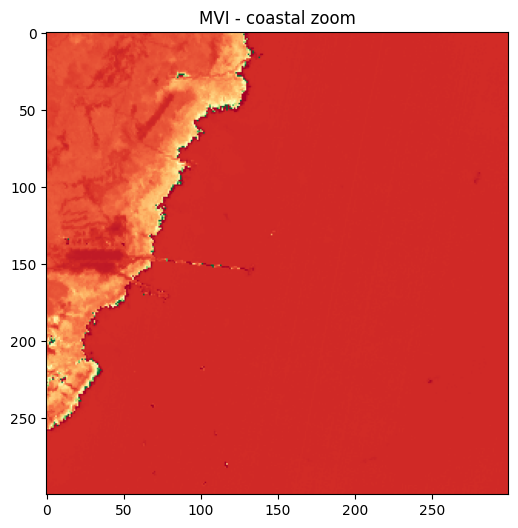

In [15]:
# Zoom to coastal area (land-water boundary)
mvi = indices['MVI']
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mvi[300:600, 400:700], cmap='RdYlGn', vmin=-1, vmax=20)
ax.set_title('MVI - coastal zoom')
plt.show()

## 5. Adaptive Threshold Calibration - Sangatta

In [16]:
# ============================================================
# Coastal candidate mask -- adaptive per scene
# All thresholds derived per-scene via Otsu (no fixed parameters)
# ============================================================
candidate_mask, candidate_diag = compute_coastal_candidate_mask(
    data, indices,
    max_buffer_m=500.0,   # hard cap: mangrove constrained to tidal zone
    return_diagnostics=True
)

# Save candidate mask as GeoTIFF for use in 02_classification.ipynb
import rasterio
cand_path = DATA_PROC / f'candidate_{SITE}_{SCENE_ID}.tif'
with rasterio.open(
    cand_path, 'w',
    driver='GTiff',
    height=candidate_mask.shape[0],
    width=candidate_mask.shape[1],
    count=1, dtype='uint8',
    crs=data['crs'], transform=data['transform'],
    compress='lzw'
) as dst:
    dst.write(candidate_mask.astype(np.uint8), 1)
print(f'Candidate mask saved : {cand_path.name}')

  Coastal candidate mask:
  water_t  (MNDWI)    : 0.1680
  veg_t    (SAVI)     : 0.3006
  buffer_t (otsu)     : 45.6 px (~1367 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 57,014 (8.3%)
Candidate mask saved : candidate_sangatta_20250302_030003_92_4001.tif


In [ ]:
# ============================================================
# Diagnostic plot -- candidate mask components
# ============================================================
capped_label = '  [capped]' if candidate_diag['buffer_capped'] else ''

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

_crs, _tr = data['crs'], data['transform']
for _ax, _arr, _cmap, _title in [
    (axes[0], candidate_diag['water_mask'].astype('float32'), 'Blues',
     f'Water mask (MNDWI > {candidate_diag["water_t"]:.3f})'),
    (axes[1], candidate_diag['veg_mask'].astype('float32'),  'Greens',
     f'Vegetation mask (SAVI > {candidate_diag["veg_t"]:.3f})'),
    (axes[2], candidate_diag['dist_px'],                     'magma',
     (f'Distance from water (px)\n'
      f'otsu={candidate_diag["buffer_otsu_px"]:.0f} px  '
      f'final={candidate_diag["buffer_t_px"]:.0f} px (~{candidate_diag["buffer_t_m"]:.0f} m)'
      f'{capped_label}')),
    (axes[3], candidate_mask.astype('float32'),              'YlGn',
     'Coastal candidate zone'),
]:
    _img, _ext = reproject_array_to_4326(_arr, _crs, _tr)
    _vmax = candidate_diag['buffer_t_px'] * 3 if _ax is axes[2] else None
    _ax.imshow(_img, extent=_ext, origin='upper', cmap=_cmap,
               **(dict(vmax=_vmax) if _vmax is not None else {}))
    _ax.set_aspect('equal')
    _add_basemap(_ax)
    _ax.set_title(_title)
    format_map_axes(_ax, fontsize=8)

plt.suptitle(f'Adaptive Coastal Candidate Mask -- {SITE}', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / f'candidate_mask_{SITE}.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# Per-scene adaptive threshold calibrated within candidate zone
# MVI uses Otsu directly (right-skewed distribution -- bimodal
# valley detection picks an overly strict threshold for MVI)
# ============================================================
import json

thresholds = apply_adaptive_threshold(
    indices, scene_id=SCENE_ID,
    candidate_mask=candidate_mask,
    force_otsu_indices=['MVI'],
)

thresh_path = ROOT / 'outputs' / 'results' / f'thresholds_{SITE}_{SCENE_ID}.json'
with open(thresh_path, 'w') as f:
    json.dump(
        {k: float(v) for k, v in thresholds.items()
         if v is not None and np.isfinite(v)}, f, indent=2
    )
print(f'Thresholds saved : {thresh_path.name}')



  Adaptive thresholds (domain=candidate-zone) -- scene: 20250302_030003_92_4001
  NDVI    : threshold = 0.8744  [bimodal]
  MNDWI   : threshold = -0.4707  [bimodal]
  NDMI    : threshold = 0.2464  [bimodal]
  CMRI    : threshold = 1.3364  [bimodal]
  NDRE    : threshold = 0.4502  [bimodal]
  SAVI    : threshold = 0.6209  [bimodal]
  MVI     : threshold = 4.0449  [otsu_forced]
  EMI     : threshold = 0.7158  [bimodal]
Thresholds saved : thresholds_sangatta_20250302_030003_92_4001.json


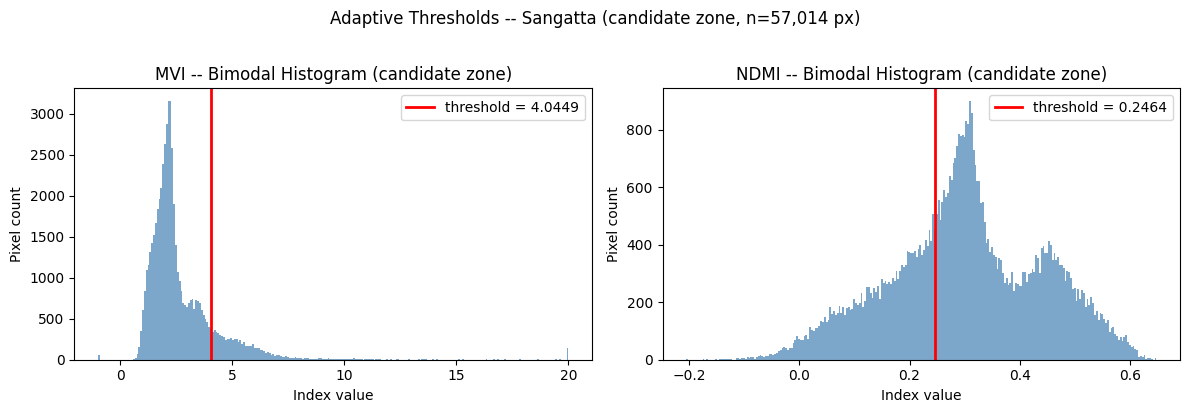

In [19]:
# ============================================================
# Diagnostic plot -- histogram + threshold lines for MVI + NDMI
# Histogram restricted to candidate zone (consistent with how
# thresholds were calibrated)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, ['MVI', 'NDMI']):
    arr  = indices[name]
    flat = arr[candidate_mask & np.isfinite(arr)].ravel()
    ax.hist(flat, bins=256, color='steelblue', alpha=0.7)
    if thresholds.get(name) is not None:
        ax.axvline(thresholds[name], color='red', linewidth=2,
                   label=f'threshold = {thresholds[name]:.4f}')
    ax.set_title(f'{name} -- Bimodal Histogram (candidate zone)')
    ax.set_xlabel('Index value')
    ax.set_ylabel('Pixel count')
    ax.legend()

plt.suptitle(f'Adaptive Thresholds -- Sangatta (candidate zone, n={candidate_mask.sum():,} px)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'thresholds_sangatta.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Hyperspectral Diagnostic Feature

Tanager's 426-band spectrum enables a physically-grounded feature that broadband multispectral sensors (Sentinel-2, Landsat) cannot reproduce. It is used as an additional input to the RF/XGBoost classifier. The adaptive threshold and pseudo-labels remain based on the 8 spectral indices only.

### 6a. Red-edge Inflection Point (REIP)

Wavelength of maximum first derivative in the red-edge region (670-760 nm). Mangrove shows a sharp sigmoid rise (~660-760 nm) due to high chlorophyll content, while non-mangrove surfaces are flatter. REIP requires ~19 narrow contiguous bands and cannot be derived from broadband sensors.

In [ ]:
# ============================================================
# Load full 426-band HDF5 spectrum for the current scene
# REIP needs the full cube, so use load_hdf5() (not the 6-band GeoTIFF)
# ============================================================
hdf5_data = load_hdf5(str(h5_path(SITE)))          # full 426-band spectrum
print(f"HDF5 loaded : {hdf5_data['reflectance'].shape[0]} bands")

In [21]:
# ============================================================
# Compute REIP from full HDF5 spectrum (red-edge 670-760nm)
# ============================================================
reip_map  = compute_reip(hdf5_data, left_nm=670, right_nm=760)

reip_path = DATA_PROC / f'reip_{SITE}_{SCENE_ID}.tif'
with rasterio.open(
    reip_path, 'w', driver='GTiff',
    height=reip_map.shape[0], width=reip_map.shape[1],
    count=1, dtype='float32',
    crs=hdf5_data['crs'], transform=hdf5_data['transform'],
    compress='lzw', nodata=np.nan,
) as dst:
    dst.write(reip_map, 1)
print(f'REIP saved : {reip_path.name}')

  REIP (red-edge inflection point):
  window         : 669 - 759 nm (19 bands)
  valid px       : 497,797
  REIP range     : 671.8 to 756.6 nm
  REIP mean      : 725.8 nm
REIP saved : reip_sangatta_20250302_030003_92_4001.tif


## 7. Full Pipeline Loop - All Sites

Runs the complete pipeline (HDF5 conversion, indices, candidate mask, adaptive threshold) for all 5 transfer sites. The hyperspectral feature (REIP) is computed per site from the full HDF5 spectrum.

In [22]:
# ============================================================
# Full pipeline loop - all sites
# Convert HDF5 → GeoTIFF → indices → adaptive threshold → save
# Skip conversion if multiband GeoTIFF already exists
# ============================================================
import json

all_thresholds = {}

for site, scene_id in SCENES.items():
    print(f'\n{"="*50}')
    print(f'  Site: {site.upper()}  ({scene_id})')
    print(f'{"="*50}')

    hp       = h5_path(site)
    tif_path = DATA_PROC / f'{site}_{scene_id}_bands.tif'

    # Step 1: Convert HDF5 → multiband GeoTIFF (skip if exists)
    if tif_path.exists():
        print(f'  GeoTIFF exists - skipping conversion')
    else:
        if not hp.exists():
            print(f'  SKIP - HDF5 not found')
            continue
        hdf5_to_geotiff(str(hp), str(DATA_PROC), scene_id, site=site)

    # Step 2: Load bands
    data = load_geotiff_bands(str(DATA_PROC), scene_id, site=site)

    # Step 3: Compute indices
    indices = compute_all_indices(data)

    # Step 4: Adaptive threshold
    candidate_mask = compute_coastal_candidate_mask(
        data, indices,
        max_buffer_m=500.0,   # hard cap consistent across all sites
    )

    # Save candidate mask
    cand_path = DATA_PROC / f'candidate_{site}_{scene_id}.tif'
    with rasterio.open(
        cand_path, 'w', driver='GTiff',
        height=candidate_mask.shape[0], width=candidate_mask.shape[1],
        count=1, dtype='uint8',
        crs=data['crs'], transform=data['transform'], compress='lzw'
    ) as dst:
        dst.write(candidate_mask.astype(np.uint8), 1)

    # Step 4b: Adaptive threshold (constrained to candidate zone)
    thresholds = apply_adaptive_threshold(
        indices, scene_id=scene_id, candidate_mask=candidate_mask,
        force_otsu_indices=['MVI'],
    )
    all_thresholds[site] = thresholds

    # Step 5: Save threshold JSON per site
    thresh_path = ROOT / 'outputs' / 'results' / f'thresholds_{site}_{scene_id}.json'
    with open(thresh_path, 'w') as f:
        json.dump({k: float(v) for k, v in thresholds.items() if v is not None}, f, indent=2)
    print(f'  Thresholds saved : {thresh_path.name}')

    # Step 6: Hyperspectral diagnostic feature (full HDF5 spectrum)
    if hp.exists():
        hdf5_data_site = load_hdf5(str(hp))

        reip      = compute_reip(hdf5_data_site, left_nm=670, right_nm=760)
        reip_path = DATA_PROC / f'reip_{site}_{scene_id}.tif'
        with rasterio.open(
            reip_path, 'w', driver='GTiff',
            height=reip.shape[0], width=reip.shape[1],
            count=1, dtype='float32',
            crs=hdf5_data_site['crs'], transform=hdf5_data_site['transform'],
            compress='lzw', nodata=np.nan,
        ) as dst:
            dst.write(reip, 1)
        print(f'  REIP saved : {site}')
    else:
        print(f'  HDF5 not found -- skipping hyperspectral feature for {site}')

print(f'\nDone - {len(all_thresholds)} sites processed.')


  Site: SANGATTA  (20250302_030003_92_4001)
  GeoTIFF exists - skipping conversion


  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 50N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : 0.1680
  veg_t    (SAVI)     : 0.3006
  buffer_t (otsu)     : 45.6 px (~1367 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 57,014 (8.3%)



  Adaptive thresholds (domain=candidate-zone) -- scene: 20250302_030003_92_4001
  NDVI    : threshold = 0.8744  [bimodal]
  MNDWI   : threshold = -0.4707  [bimodal]
  NDMI    : threshold = 0.2464  [bimodal]
  CMRI    : threshold = 1.3364  [bimodal]
  NDRE    : threshold = 0.4502  [bimodal]
  SAVI    : threshold = 0.6209  [bimodal]
  MVI     : threshold = 4.0449  [otsu_forced]
  EMI     : threshold = 0.7158  [bimodal]
  Thresholds saved : thresholds_sangatta_20250302_030003_92_4001.json
  HDF5 loaded     : sangatta_20250302_030003_92_4001_ortho_sr_hdf5.h5
  Shape (B,H,W)   : (426, 850, 810)
  CRS             : EPSG:32650
  Pixel size      : 30.0 m
  Wavelength range: 380-2500 nm
  REIP (red-edge inflection point):
  window         : 669 - 759 nm (19 bands)
  valid px       : 497,797
  REIP range     : 671.8 to 756.6 nm
  REIP mean      : 725.8 nm


  REIP saved : sangatta

  Site: GUJARAT  (20250311_061550_53_4001)
  GeoTIFF exists - skipping conversion
  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : 0.1320
  veg_t    (SAVI)     : 0.0608
  buffer_t (otsu)     : 21.5 px (~644 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 137,506 (21.6%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250311_061550_53_4001
  NDVI  

  REIP saved : gujarat

  Site: ELSALVADOR  (20250223_165546_32_4001)
  GeoTIFF exists - skipping conversion
  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : -0.0422
  veg_t    (SAVI)     : 0.2198
  buffer_t (otsu)     : 60.9 px (~1826 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 115,363 (22.4%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250223_165546_32_4001
  N

  REIP saved : elsalvador

  Site: BELIZE  (20250824_171853_67_4001)
  GeoTIFF exists - skipping conversion
  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : -0.0992
  veg_t    (SAVI)     : 0.3525
  buffer_t (otsu)     : 32.0 px (~961 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 118,612 (23.1%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250824_171853_67_4001
  NDV

  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : -0.0877
  veg_t    (SAVI)     : 0.2676
  buffer_t (otsu)     : 33.6 px (~1009 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 105,739 (20.7%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250824_171857_84_4001
  NDVI    : threshold = 0.7958  [bimodal]
  MNDWI   : threshold = -0.3788  [bimodal]
  NDMI    : threshold = 0.3

  REIP saved : belize2

  Site: AUSTRALIA  (20250608_014315_58_4001)
  GeoTIFF exists - skipping conversion
  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 53S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : 0.2294
  veg_t    (SAVI)     : 0.1543
  buffer_t (otsu)     : 65.1 px (~1953 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 122,740 (20.1%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250608_014315_58_400

In [23]:
print("HDF5 shape    :", hdf5_data['reflectance'].shape[1:])   # (850, 810)
print("reip_map shape:", reip_map.shape)                       # follows HDF5
print("indices shape :", indices['NDMI'].shape)                # (667, 915)

HDF5 shape    : (850, 810)
reip_map shape: (850, 810)
indices shape : (667, 915)


In [24]:
import inspect, importlib
import src.spectral_resampling as _srf

# Refresh the module in memory so line numbers match the file on disk!
importlib.reload(_srf)

source = inspect.getsource(_srf.compute_scenario_b_indices)
print('MVI_CLIP' in source)       # harus True
print('blockxsize' in inspect.getsource(_srf.write_scenario_b_outputs).lower())  # harus True


True
True
